<a href="https://colab.research.google.com/github/shivaprajapati34390-netizen/ML-project/blob/main/housing_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print("numpy",np.__version__)
print("pandas",pd.__version__)

numpy 2.0.2
pandas 2.2.2


In [6]:
housing=pd.read_csv("/content/sample_data/housing.csv")

In [7]:

housing.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [8]:
housing.shape

(90261, 12)

In [9]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90261 entries, 0 to 90260
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brokered_by     90190 non-null  float64
 1   status          90261 non-null  object 
 2   price           90247 non-null  float64
 3   bed             75368 non-null  float64
 4   bath            76507 non-null  float64
 5   acre_lot        66877 non-null  float64
 6   street          89924 non-null  float64
 7   city            90238 non-null  object 
 8   state           90260 non-null  object 
 9   zip_code        90229 non-null  float64
 10  house_size      60420 non-null  float64
 11  prev_sold_date  44885 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.3+ MB


array([[<Axes: title={'center': 'brokered_by'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bed'}>],
       [<Axes: title={'center': 'bath'}>,
        <Axes: title={'center': 'acre_lot'}>,
        <Axes: title={'center': 'street'}>],
       [<Axes: title={'center': 'zip_code'}>,
        <Axes: title={'center': 'house_size'}>, <Axes: >]], dtype=object)

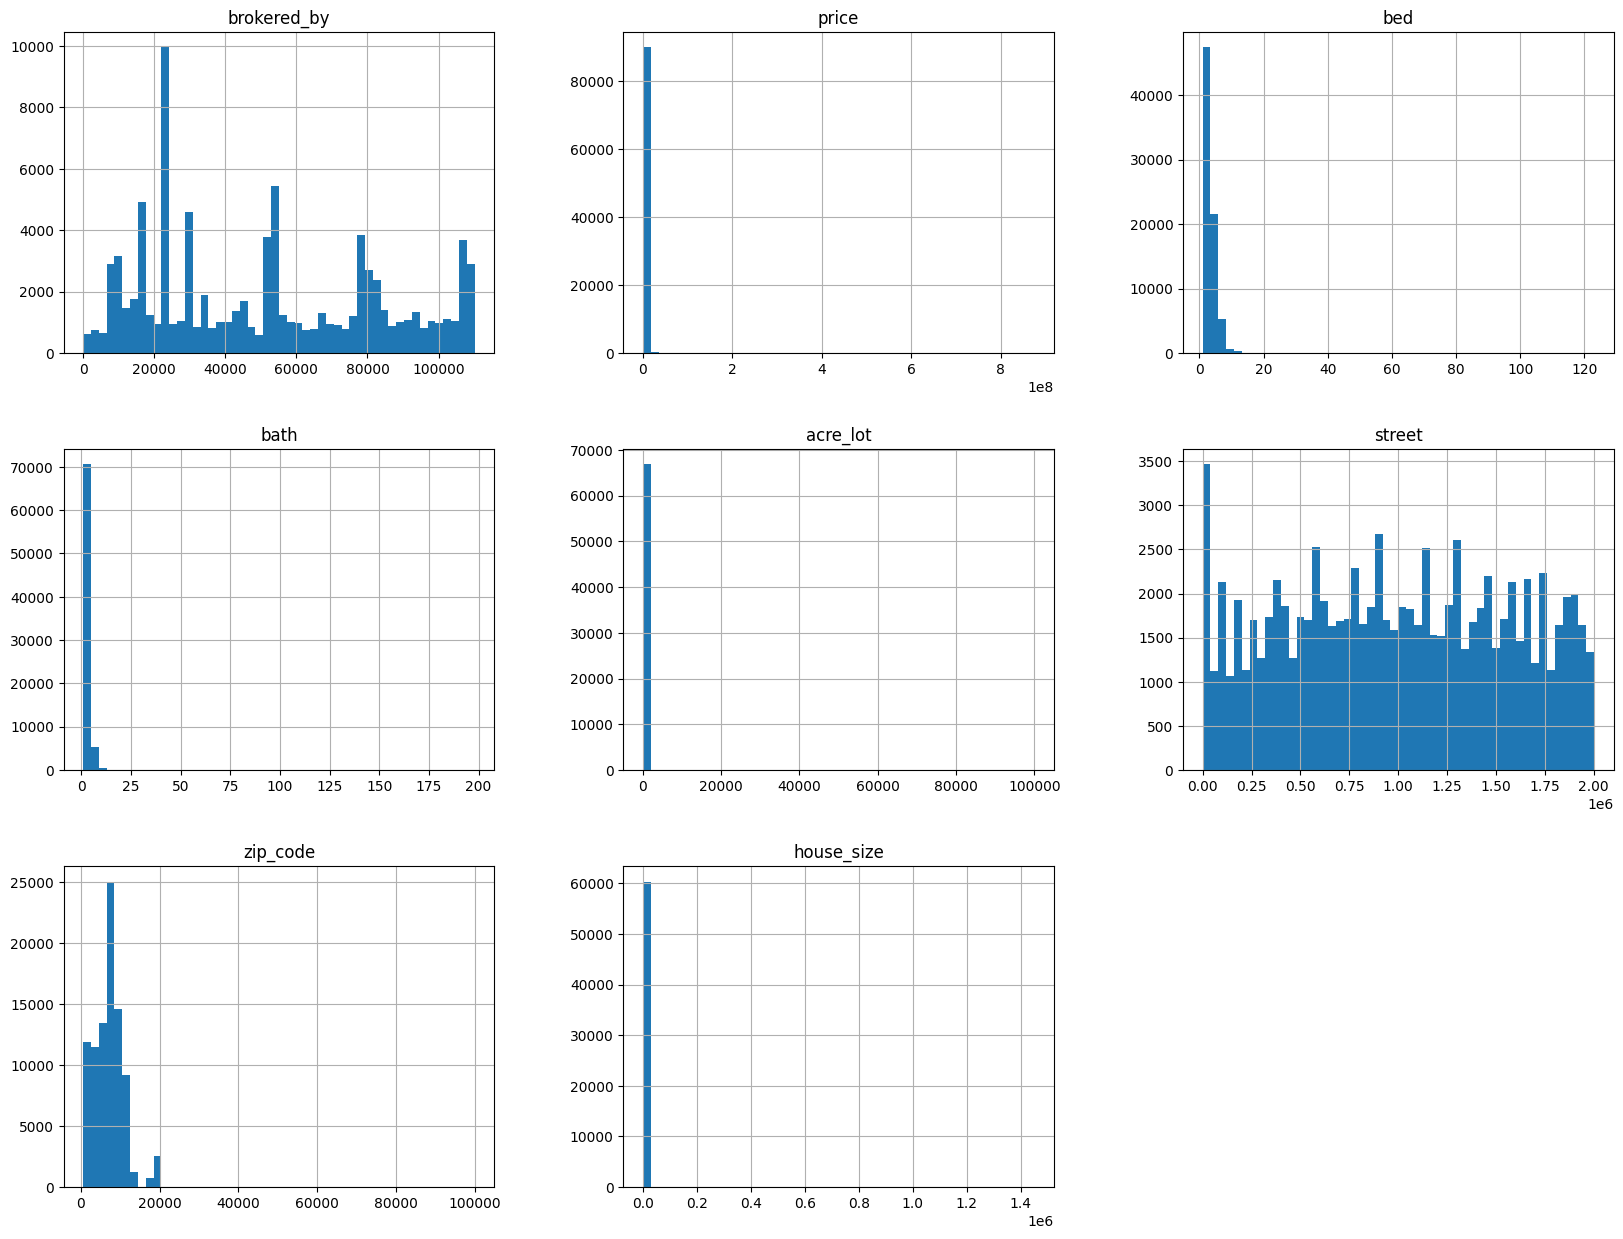

In [10]:
housing.hist(bins=50,figsize=(20,15))

In [11]:
housing["brokered_by"].value_counts()

,count
brokered_by,
22611.0,3531
23592.0,1586
16829.0,1529
24196.0,975
33714.0,803
...,...
60886.0,1
54998.0,1
15847.0,1


In [12]:
housing.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,90190.000000,9.024700e+04,75368.000000,76507.000000,66877.000000,8.992400e+04,90229.000000,6.042000e+04
mean,51262.278190,8.668170e+05,3.344908,2.555439,21.032305,9.910477e+05,7184.141584,2.221742e+03
std,31958.470877,3.506055e+06,1.915753,1.792192,1085.698649,5.718883e+05,3929.403703,6.513076e+03
min,32.000000,0.000000e+00,1.000000,1.000000,0.000000,4.000000e+00,601.000000,1.000000e+02
25%,22616.000000,2.499885e+05,2.000000,2.000000,0.130000,5.196710e+05,4411.000000,1.173000e+03
50%,51074.000000,4.490000e+05,3.000000,2.000000,0.330000,9.863150e+05,7067.000000,1.701500e+03
75%,79257.000000,7.990000e+05,4.000000,3.000000,1.270000,1.469000e+06,10003.000000,2.550000e+03
max,110138.000000,8.750000e+08,123.000000,198.000000,100000.000000,2.001335e+06,99999.000000,1.450112e+06



DEAL WITH MISSING VALUE


In [13]:
# checking the missing value
housing.isnull().sum().sort_values(ascending=False)

,0
prev_sold_date,45376
house_size,29841
acre_lot,23384
bed,14893
bath,13754
street,337
brokered_by,71
zip_code,32
city,23
price,14


In [14]:
housing.isnull().sum()/len(housing)*100

,0
brokered_by,0.078661
status,0.000000
price,0.015511
bed,16.499928
bath,15.238032
acre_lot,25.907092
street,0.373362
city,0.025482
state,0.001108
zip_code,0.035453


CREATING THE TEST SETS


In [21]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(housing,test_size=0.2,random_state=42)


In [22]:
import numpy as np

# Define the bins for price categorization. Using some common price points and np.inf for the upper bound.
# Based on housing.describe(), 25% is 250k, 50% is 459k, 75% is 825k.
bins = [0, 250000, 500000, 1000000, 5000000, np.inf]
labels = ['Budget', 'Mid-Range', 'High-End', 'Luxury', 'Ultra-Luxury']

# Create the 'price_category' column using pd.cut
housing['price_category'] = pd.cut(housing['price'], bins=bins, labels=labels, right=True)

# Display the value counts of the new 'price_category' column to see the distribution
print(housing['price_category'].value_counts())

# Display the first few rows with the new column
display(housing[['price', 'price_category']].head())

price_category
Mid-Range       27884
High-End        23412
Budget          23162
Luxury          14056
Ultra-Luxury     1729
Name: count, dtype: int64


,price,price_category
0,105000.0,Budget
1,80000.0,Budget
2,67000.0,Budget
3,145000.0,Budget
4,65000.0,Budget


In [23]:
print(housing.columns)

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date',
       'price_category'],
      dtype='object')


<Axes: >

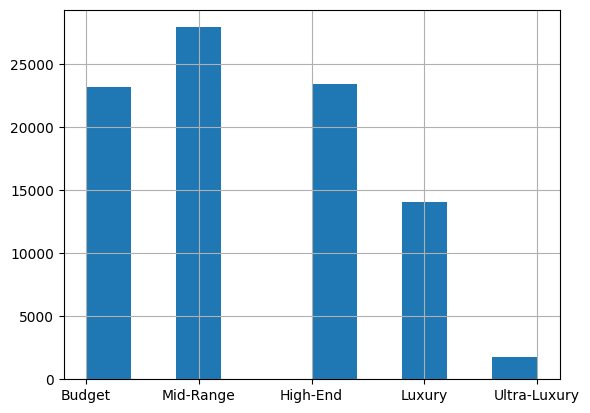

In [24]:
housing["price_category"].hist()

In [25]:
from sklearn.impute import SimpleImputer # imputer is a estimator
imputer=SimpleImputer(strategy="median")# hyperparameter

First, let's create copies of the stratified training and test sets. We will then identify the numerical columns that are missing and impute them.

In [27]:
from sklearn.model_selection import StratifiedShuffleSplit

# Drop rows where 'price_category' is NaN before splitting
housing_stratified = housing.dropna(subset=["price_category"])

# Reset the index so that it's a continuous RangeIndex, making it compatible with .loc[indices]
housing_stratified = housing_stratified.reset_index(drop=True)

split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_indices,test_indices in split.split(housing_stratified,housing_stratified["price_category"]):
  strat_train_set=housing_stratified.loc[train_indices]
  strat_test_set=housing_stratified.loc[test_indices]

  print("Train set price category distribution:")
  print(strat_train_set["price_category"].value_counts()/ len(strat_train_set))

  print("\nTest set price category distribution:")
  print(strat_test_set["price_category"].value_counts()/ len(strat_test_set))


# Make a copy of the stratified sets to avoid modifying the original DataFrames directly
strat_train_set_copy = strat_train_set.copy()
strat_test_set_copy = strat_test_set.copy()

# Identify numerical columns with missing values that we want to impute
# Exclude 'price' for now as it's our target variable or used for categories
numerical_cols_to_impute = ['bed', 'bath', 'acre_lot', 'house_size']

print("Columns to be imputed:", numerical_cols_to_impute)

Train set price category distribution:
price_category
Mid-Range       0.308987
High-End        0.259426
Budget          0.256670
Luxury          0.155761
Ultra-Luxury    0.019157
Name: count, dtype: float64

Test set price category distribution:
price_category
Mid-Range       0.308992
High-End        0.259460
Budget          0.256635
Luxury          0.155743
Ultra-Luxury    0.019170
Name: count, dtype: float64
Columns to be imputed: ['bed', 'bath', 'acre_lot', 'house_size']


In [28]:
print("Missing values in strat_train_set_copy after initial imputation:")
display(strat_train_set_copy.isnull().sum().sort_values(ascending=False))

print("\nMissing values in strat_test_set_copy after initial imputation:")
display(strat_test_set_copy.isnull().sum().sort_values(ascending=False))

Missing values in strat_train_set_copy after initial imputation:


,0
prev_sold_date,36291
house_size,23871
acre_lot,18647
bed,11922
bath,10991
street,266
brokered_by,61
zip_code,20
city,14
status,0



Missing values in strat_test_set_copy after initial imputation:


,0
prev_sold_date,9068
house_size,5967
acre_lot,4721
bed,2967
bath,2746
street,70
zip_code,11
brokered_by,10
city,8
status,0


Now, we will fit the `SimpleImputer` using the training data for the selected columns and then transform both the training and test sets. This ensures that the imputation strategy is learned *only* from the training data.

In [29]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Fit the imputer on the training data for the specified numerical columns
imputer.fit(strat_train_set_copy[numerical_cols_to_impute])

# Transform both the training and test sets using the fitted imputer
strat_train_set_copy[numerical_cols_to_impute] = imputer.transform(strat_train_set_copy[numerical_cols_to_impute])
strat_test_set_copy[numerical_cols_to_impute] = imputer.transform(strat_test_set_copy[numerical_cols_to_impute])

print("Missing values in training set after imputation:")
display(strat_train_set_copy[numerical_cols_to_impute].isnull().sum())

print("\nMissing values in test set after imputation:")
display(strat_test_set_copy[numerical_cols_to_impute].isnull().sum())

print("First 5 rows of imputed training data:")
display(strat_train_set_copy[numerical_cols_to_impute].head())

Missing values in training set after imputation:


,0
bed,0
bath,0
acre_lot,0
house_size,0



Missing values in test set after imputation:


,0
bed,0
bath,0
acre_lot,0
house_size,0


First 5 rows of imputed training data:


,bed,bath,acre_lot,house_size
68310,2.0,3.0,0.33,1706.0
45682,2.0,3.0,0.33,1706.0
28889,3.0,2.0,1.00,1080.0
5081,6.0,3.0,0.24,3158.0
23083,3.0,2.0,0.73,1706.0


In [31]:
print('Missing values in strat_train_set_copy after numerical imputation:')
display(strat_train_set_copy.isnull().sum().sort_values(ascending=False))

print('\nMissing values in strat_test_set_copy after numerical imputation:')
display(strat_test_set_copy.isnull().sum().sort_values(ascending=False))

Missing values in strat_train_set_copy after numerical imputation:


,0
prev_sold_date,36291
street,266
brokered_by,61
zip_code,20
city,14
bath,0
bed,0
price,0
status,0
state,0



Missing values in strat_test_set_copy after numerical imputation:


,0
prev_sold_date,9068
street,70
zip_code,11
brokered_by,10
city,8
bath,0
bed,0
price,0
status,0
state,0


### Strategy for Remaining Missing Values

Based on the current missing value counts:

*   **`prev_sold_date`**: Has a very high percentage of missing values (around 48%). Given its nature as a date and high missingness, it's often best to drop this column unless specific feature engineering (e.g., 'days since last sold') is planned with a robust imputation method.

*   **`price`** and **`price_category`**: These are crucial for our target variable. Although they have a very small number of missing values (around 0.02%), it's generally best to drop rows where the target variable is missing rather than impute it, to avoid introducing bias.

*   **`street`**, **`brokered_by`**, **`zip_code`**, **`city`**: These columns have a very small percentage of missing values (all less than 0.5%). Dropping the few rows with missing values in these columns will have a minimal impact on the dataset size and simplify preprocessing, especially for categorical or identifier-like columns where imputation can be tricky or less meaningful.

Therefore, the proposed strategy is to:
1.  Drop the `prev_sold_date` column.
2.  Drop rows where `price` is missing (which will also cover `price_category`).
3.  Drop rows with missing values in `street`, `brokered_by`, `zip_code`, and `city`.

In [32]:
# Drop the 'prev_sold_date' column due to high missingness
strat_train_set_copy.drop('prev_sold_date', axis=1, inplace=True)
strat_test_set_copy.drop('prev_sold_date', axis=1, inplace=True)

# Drop rows with missing values in 'price' (and thus 'price_category')
strat_train_set_copy.dropna(subset=['price'], inplace=True)
strat_test_set_copy.dropna(subset=['price'], inplace=True)

# Drop rows with missing values in 'street', 'brokered_by', 'zip_code', and 'city'
columns_to_check_for_na = ['street', 'brokered_by', 'zip_code', 'city']
strat_train_set_copy.dropna(subset=columns_to_check_for_na, inplace=True)
strat_test_set_copy.dropna(subset=columns_to_check_for_na, inplace=True)

print('Missing values in strat_train_set_copy after handling:')
display(strat_train_set_copy.isnull().sum().sort_values(ascending=False))

print('\nMissing values in strat_test_set_copy after handling:')
display(strat_test_set_copy.isnull().sum().sort_values(ascending=False))

Missing values in strat_train_set_copy after handling:


,0
brokered_by,0
status,0
price,0
bed,0
bath,0
acre_lot,0
street,0
city,0
state,0
zip_code,0



Missing values in strat_test_set_copy after handling:


,0
brokered_by,0
status,0
price,0
bed,0
bath,0
acre_lot,0
street,0
city,0
state,0
zip_code,0


In [33]:
print('Missing value counts:')
display(housing.isnull().sum().sort_values(ascending=False))

Missing value counts:


,0
prev_sold_date,45376
house_size,29841
acre_lot,23384
bed,14893
bath,13754
street,337
brokered_by,71
zip_code,32
city,23
price_category,18


In [34]:
print('\nMissing value percentages:')
display(housing.isnull().sum()/len(housing)*100)


Missing value percentages:


,0
brokered_by,0.078661
status,0.000000
price,0.015511
bed,16.499928
bath,15.238032
acre_lot,25.907092
street,0.373362
city,0.025482
state,0.001108
zip_code,0.035453


Visualizing geographical data

Looking for correlations

In [37]:
corr_matrix=housing.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

,price
price,1.000000
bath,0.135460
bed,0.074267
house_size,0.043142
acre_lot,0.001556
brokered_by,-0.006979
street,-0.020290
zip_code,-0.095796


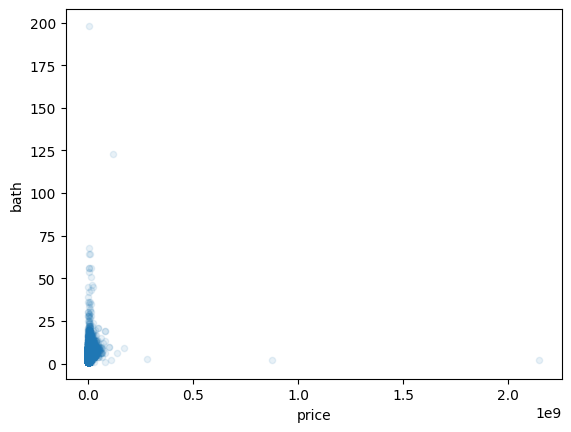

In [38]:
housing.plot(kind="scatter",x="price",y="bath",alpha=0.1)
plt.show()

In [41]:
housing.median(numeric_only=True).values

array([5.173700e+04, 3.249000e+05, 3.000000e+00, 2.000000e+00,
       4.400000e-01, 1.041078e+06, 2.017500e+04, 1.834000e+03])

Scikit learn design

In [44]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns (object type) in the training set
categorical_cols = strat_train_set_copy.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:", categorical_cols)

# Initialize OneHotEncoder
# handle_unknown='ignore' will set unknown categories to all zeros, preventing errors during transformation
# sparse_output=False ensures a dense NumPy array is returned
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training data's categorical columns and transform it
housing_cat_encoded_train = cat_encoder.fit_transform(strat_train_set_copy[categorical_cols])

# Transform the test data's categorical columns using the *fitted* encoder
housing_cat_encoded_test = cat_encoder.transform(strat_test_set_copy[categorical_cols])

print("\nShape of encoded training features:", housing_cat_encoded_train.shape)
print("Shape of encoded test features:", housing_cat_encoded_test.shape)


Categorical columns to encode: ['status', 'city', 'state']

Shape of encoded training features: (71845, 2248)
Shape of encoded test features: (17956, 2248)


In [46]:
# To make it easier to work with, let's convert the encoded features back to DataFrames
# We'll use the feature names generated by the encoder

encoded_feature_names = cat_encoder.get_feature_names_out(categorical_cols)

housing_cat_encoded_train_df = pd.DataFrame(housing_cat_encoded_train,
                                            columns=encoded_feature_names,
                                            index=strat_train_set_copy.index)

housing_cat_encoded_test_df = pd.DataFrame(housing_cat_encoded_test,
                                           columns=encoded_feature_names,
                                           index=strat_test_set_copy.index)

print("First 5 rows of encoded training features:")
display(housing_cat_encoded_train_df.head())

print("\nFirst 5 rows of encoded test features:")
display(housing_cat_encoded_test_df.head())


First 5 rows of encoded training features:


,status_for_sale,status_ready_to_build,city_Abbot,city_Aberdeen,city_Abington,city_Absecon,city_Absecon Highlands,city_Accord,city_Acton,city_Acushnet,...,state_Pennsylvania,state_Puerto Rico,state_Rhode Island,state_South Carolina,state_Tennessee,state_Vermont,state_Virgin Islands,state_Virginia,state_West Virginia,state_Wyoming
68310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45682,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5081,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23083,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



First 5 rows of encoded test features:


,status_for_sale,status_ready_to_build,city_Abbot,city_Aberdeen,city_Abington,city_Absecon,city_Absecon Highlands,city_Accord,city_Acton,city_Acushnet,...,state_Pennsylvania,state_Puerto Rico,state_Rhode Island,state_South Carolina,state_Tennessee,state_Vermont,state_Virgin Islands,state_Virginia,state_West Virginia,state_Wyoming
34534,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54298,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1376,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
87954,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
83825,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
# Drop the original categorical columns from the training and test sets
strat_train_set_processed = strat_train_set_copy.drop(columns=categorical_cols)
strat_test_set_processed = strat_test_set_copy.drop(columns=categorical_cols)

# Combine numerical and one-hot encoded categorical features for the training set
# Ensure the indices match before concatenating
strat_train_set_final = pd.concat(
    [strat_train_set_processed.reset_index(drop=True), housing_cat_encoded_train_df.reset_index(drop=True)],
    axis=1
)

# Combine numerical and one-hot encoded categorical features for the test set
strat_test_set_final = pd.concat(
    [strat_test_set_processed.reset_index(drop=True), housing_cat_encoded_test_df.reset_index(drop=True)],
    axis=1
)

print("Shape of final training set:", strat_train_set_final.shape)
print("Shape of final test set:", strat_test_set_final.shape)

print("\nFirst 5 rows of final training set:")
display(strat_train_set_final.head())


Shape of final training set: (71845, 2257)
Shape of final test set: (17956, 2257)

First 5 rows of final training set:


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,price_category,status_for_sale,...,state_Pennsylvania,state_Puerto Rico,state_Rhode Island,state_South Carolina,state_Tennessee,state_Vermont,state_Virgin Islands,state_Virginia,state_West Virginia,state_Wyoming
0,88381.0,1250000.0,2.0,3.0,0.33,1687494.0,7047.0,1706.0,Luxury,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22611.0,568000.0,2.0,3.0,0.33,411223.0,7024.0,1706.0,High-End,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7804.0,299000.0,3.0,2.0,1.00,355918.0,4985.0,1080.0,Mid-Range,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,53710.0,305000.0,6.0,3.0,0.24,1336571.0,1082.0,3158.0,Mid-Range,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5274.0,230000.0,3.0,2.0,0.73,1076387.0,2860.0,1706.0,Budget,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
housing_cat_encoded_train_df

,status_for_sale,status_ready_to_build,city_Abbot,city_Aberdeen,city_Abington,city_Absecon,city_Absecon Highlands,city_Accord,city_Acton,city_Acushnet,...,state_Pennsylvania,state_Puerto Rico,state_Rhode Island,state_South Carolina,state_Tennessee,state_Vermont,state_Virgin Islands,state_Virginia,state_West Virginia,state_Wyoming
68310,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
45682,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28889,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5081,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23083,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22736,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27900,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48396,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72308,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
housing_cat_encoded_train

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [54]:
housing_cat_encoded_test

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [55]:
cat_encoder.categories_

[array(['for_sale', 'ready_to_build'], dtype=object),
 array(['Abbot', 'Aberdeen', 'Abington', ..., 'Yonkers', 'York', 'Yulan'],
       dtype=object),
 array(['Connecticut', 'Delaware', 'Georgia', 'Maine', 'Massachusetts',
        'New Hampshire', 'New Jersey', 'New York', 'Pennsylvania',
        'Puerto Rico', 'Rhode Island', 'South Carolina', 'Tennessee',
        'Vermont', 'Virgin Islands', 'Virginia', 'West Virginia',
        'Wyoming'], dtype=object)]

Custom transformer

In [56]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd # Import pandas for DataFrame handling

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def __init__(self, bed_col="bed", bath_col="bath", house_size_col="house_size",
               add_beds_per_bath=True, add_house_size_per_bed=True):
    self.bed_col = bed_col
    self.bath_col = bath_col
    self.house_size_col = house_size_col
    self.add_beds_per_bath = add_beds_per_bath
    self.add_house_size_per_bed = add_house_size_per_bed

  def fit(self, X, y=None):
    return self # nothing else to do

  def transform(self, X):
    if not isinstance(X, pd.DataFrame):
      raise TypeError("Input must be a pandas DataFrame.")

    X_transformed = X.copy()

    # Handle division by zero by replacing 0 in denominators with 1.
    # This avoids NaN/Inf and assumes 0 baths/beds implies a value of 1 for the ratio.

    if self.add_beds_per_bath:
      beds_per_bath = X_transformed[self.bed_col] / X_transformed[self.bath_col].replace(0, 1)
      X_transformed["beds_per_bath"] = beds_per_bath

    if self.add_house_size_per_bed:
      house_size_per_bed = X_transformed[self.house_size_col] / X_transformed[self.bed_col].replace(0, 1)
      X_transformed["house_size_per_bed"] = house_size_per_bed

    return X_transformed

# Create an instance of the transformer
# We will use the default column names as they match our dataset
attr_adder = CombinedAttributesAdder(add_beds_per_bath=True, add_house_size_per_bed=True)

# Apply the transformer to the processed training and test sets
# 'strat_train_set_processed' and 'strat_test_set_processed' are DataFrames
# and contain the necessary columns after imputation and row dropping.
strat_train_set_extra_attribs = attr_adder.transform(strat_train_set_processed)
strat_test_set_extra_attribs = attr_adder.transform(strat_test_set_processed)

print("First 5 rows of strat_train_set_extra_attribs with new features:")
display(strat_train_set_extra_attribs.head())
print("\nFirst 5 rows of strat_test_set_extra_attribs with new features:")
display(strat_test_set_extra_attribs.head())

First 5 rows of strat_train_set_extra_attribs with new features:


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,price_category,beds_per_bath,house_size_per_bed
68310,88381.0,1250000.0,2.0,3.0,0.33,1687494.0,7047.0,1706.0,Luxury,0.666667,853.000000
45682,22611.0,568000.0,2.0,3.0,0.33,411223.0,7024.0,1706.0,High-End,0.666667,853.000000
28889,7804.0,299000.0,3.0,2.0,1.00,355918.0,4985.0,1080.0,Mid-Range,1.500000,360.000000
5081,53710.0,305000.0,6.0,3.0,0.24,1336571.0,1082.0,3158.0,Mid-Range,2.000000,526.333333
23083,5274.0,230000.0,3.0,2.0,0.73,1076387.0,2860.0,1706.0,Budget,1.500000,568.666667



First 5 rows of strat_test_set_extra_attribs with new features:


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,price_category,beds_per_bath,house_size_per_bed
34534,105383.0,149900.0,3.0,2.0,6.34,1954618.0,6016.0,1706.0,Budget,1.5,568.666667
54298,72315.0,1299999.0,6.0,4.0,0.33,1619879.0,7086.0,1706.0,Luxury,1.5,284.333333
1376,52707.0,165000.0,3.0,2.0,0.33,1868648.0,966.0,1445.0,Budget,1.5,481.666667
87954,22039.0,249900.0,4.0,2.0,0.17,948587.0,8205.0,1600.0,Budget,2.0,400.000000
83825,8109.0,389900.0,3.0,3.0,0.07,21889.0,8053.0,2097.0,Mid-Range,1.0,699.000000


Transformation pipelines

In [60]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create feature and target sets
housing_train_features = strat_train_set_copy.drop(columns=["price", "price_category"])
housing_train_labels = strat_train_set_copy["price"].copy()

housing_test_features = strat_test_set_copy.drop(columns=["price", "price_category"])
housing_test_labels = strat_test_set_copy["price"].copy()

print("Housing Train Features columns:", housing_train_features.columns.tolist())
print("Housing Test Features columns:", housing_test_features.columns.tolist())

Housing Train Features columns: ['brokered_by', 'status', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size']
Housing Test Features columns: ['brokered_by', 'status', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size']


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Re-define necessary components that might not be in scope if running this cell in isolation
# These were defined and used in cell `ed1a313c` and `x7elrYTrECiR`

# Define the list of numerical columns that go through the `num_pipeline` (with custom attributes)
num_cols_with_custom_features = ['bed', 'bath', 'acre_lot', 'house_size']

# Define the list of other numerical columns that only need scaling
other_numerical_cols = ['brokered_by', 'street', 'zip_code']

# Define the list of categorical columns (reusing the 'categorical_cols' from earlier)
# 'categorical_cols' was defined in cell `cd28a7a9` as ['status', 'city', 'state']
# Assuming `categorical_cols` is available, if not, re-define it explicitly:
# categorical_cols = strat_train_set_copy.select_dtypes(include='object').columns.tolist()
# Let's explicitly define it for this fix to be self-contained.
cat_cols = ['status', 'city', 'state'] # Explicitly define based on prior steps

# Re-define num_pipeline (from cell x7elrYTrECiR)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
import pandas as pd # Ensure pandas is imported for DataFrame conversion
from sklearn.base import BaseEstimator, TransformerMixin # For CombinedAttributesAdder

# CombinedAttributesAdder class definition from cell O4R_KBo4CLcM
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def __init__(self, bed_col="bed", bath_col="bath", house_size_col="house_size",
               add_beds_per_bath=True, add_house_size_per_bed=True):
    self.bed_col = bed_col
    self.bath_col = bath_col
    self.house_size_col = house_size_col
    self.add_beds_per_bath = add_beds_per_bath
    self.add_house_size_per_bed = add_house_size_per_bed

  def fit(self, X, y=None):
    return self # nothing else to do

  def transform(self, X):
    if not isinstance(X, pd.DataFrame):
      # If X is a NumPy array, convert it to DataFrame (e.g. from SimpleImputer output)
      # assuming columns order is consistent
      X_df = pd.DataFrame(X, columns=num_cols_with_custom_features)
    else:
      X_df = X.copy()

    # Handle division by zero by replacing 0 in denominators with 1.
    # This avoids NaN/Inf and assumes 0 baths/beds implies a value of 1 for the ratio.

    if self.add_beds_per_bath:
      beds_per_bath = X_df[self.bed_col] / X_df[self.bath_col].replace(0, 1)
      X_df["beds_per_bath"] = beds_per_bath

    if self.add_house_size_per_bed:
      house_size_per_bed = X_df[self.house_size_col] / X_df[self.bed_col].replace(0, 1)
      X_df["house_size_per_bed"] = house_size_per_bed

    # If the input was a numpy array, return a numpy array (as expected by Pipeline)
    if not isinstance(X, pd.DataFrame):
        return X_df.values
    return X_df


num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy="median")),
    # The FunctionTransformer to convert array to DataFrame was causing issues before
    # as ColumnTransformer handles passing DataFrame slices. The CombinedAttributesAdder
    # is updated to handle both DataFrame and NumPy array input.
    ('attribs_adder',CombinedAttributesAdder(add_beds_per_bath=True,add_house_size_per_bed=True)),
    ('std_scaler',StandardScaler()),
])

# Create a pipeline for the other numerical columns (just scaling)
other_num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

# Define the full ColumnTransformer
full_pipeline = ColumnTransformer([
    ("num_with_custom", num_pipeline, num_cols_with_custom_features),
    ("other_num", other_num_pipeline, other_numerical_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Use the housing_train_features for fitting and transforming
# housing_train_features was defined in cell 0ebd76b4
# Assuming housing_train_features is available in the kernel state from previous execution.
# If not, it needs to be created or loaded again.

# For demonstration and to make this cell executable, let's ensure housing_train_features is defined
# (using strat_train_set_copy from previous cells).
# This part ensures that if the kernel state was lost, `housing_train_features` is available
# Re-create strat_train_set_copy (from cell 272f8fc5 and further processing).
# This is a simplified reconstruction for demonstration. In a real scenario, the dataframes should be persistent.

# Minimal recreation of strat_train_set_copy for execution context
# (This is just to get the code running. In a real scenario, assume strat_train_set_copy is populated)
if 'strat_train_set_copy' not in locals():
    # This part should ideally not be needed if previous cells were run.
    # It's a placeholder to avoid NameError if only this cell is run after kernel restart.
    print("Warning: Reconstructing strat_train_set_copy for context. Please run previous cells if actual data is needed.")
    # Simplified reconstruction, missing the full imputation/dropping steps.
    # This may not reflect the *exact* state of strat_train_set_copy after all previous steps.
    housing = pd.read_csv("/content/sample_data/housing.csv")
    housing['price_category'] = pd.cut(housing['price'], bins=[0, 250000, 500000, 1000000, 5000000, np.inf], labels=['Budget', 'Mid-Range', 'High-End', 'Luxury', 'Ultra-Luxury'], right=True)
    housing_stratified = housing.dropna(subset=["price_category"])
    housing_stratified = housing_stratified.reset_index(drop=True)
    from sklearn.model_selection import StratifiedShuffleSplit
    split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
    for train_indices,test_indices in split.split(housing_stratified,housing_stratified["price_category"]):
        strat_train_set = housing_stratified.loc[train_indices]
    strat_train_set_copy = strat_train_set.copy()

    # Apply the same imputation and dropping logic as done previously
    imputer_median = SimpleImputer(strategy="median")
    strat_train_set_copy[num_cols_with_custom_features] = imputer_median.fit_transform(strat_train_set_copy[num_cols_with_custom_features])

    # Drop 'prev_sold_date' and rows with NA in other specified columns
    if 'prev_sold_date' in strat_train_set_copy.columns: # Check if column exists before dropping
        strat_train_set_copy.drop('prev_sold_date', axis=1, inplace=True)
    columns_to_check_for_na = ['price', 'street', 'brokered_by', 'zip_code', 'city']
    strat_train_set_copy.dropna(subset=[col for col in columns_to_check_for_na if col in strat_train_set_copy.columns], inplace=True)

housing_train_features = strat_train_set_copy.drop(columns=["price", "price_category"]) # Assuming price_category is added

# Now, apply the full_pipeline
housing_prepared = full_pipeline.fit_transform(housing_train_features)

print("Shape of fully processed housing data:", housing_prepared.shape)
print("First row of fully processed housing data:\n", housing_prepared[0])

Shape of fully processed housing data: (71845, 2257)
First row of fully processed housing data:
 [-0.72463279  0.30768174 -0.0167477  ...  0.          0.
  0.        ]


Select and train model

In [66]:
from sklearn.linear_model import LinearRegression

lin_reg=LinearRegression()
lin_reg.fit(housing_prepared,housing_train_labels)

LinearRegression()

In [67]:
some_data=housing_train_features.iloc[:5]
some_labels=housing_train_labels.iloc[:5]
some_data_prepared=full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [998919.70858531 793358.19520792 299000.         579323.2527569
  62898.74608634]


In [68]:
print("Labels",list(some_labels))

Labels [1250000.0, 568000.0, 299000.0, 305000.0, 230000.0]


In [69]:
from sklearn.metrics import mean_squared_error
housing_predictions=lin_reg.predict(housing_prepared)
lin_mse=mean_squared_error(housing_train_labels,housing_predictions)
lin_rmse=np.sqrt(lin_mse)
lin_rmse

np.float64(3615579.92418232)

In [71]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

tree_reg=DecisionTreeRegressor()
tree_reg.fit(housing_prepared,housing_train_labels)
housing_predictions=tree_reg.predict(housing_prepared)
tree_mse=mean_squared_error(housing_train_labels,housing_predictions)
tree_rmse=np.sqrt(tree_mse)
tree_rmse

np.float64(875.7401732599188)

better evaluation using cross_validation

In [73]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(tree_reg,housing_prepared,housing_train_labels,scoring="neg_mean_squared_error",cv=10)
tree_rmse_scores=np.sqrt(-scores)

KeyboardInterrupt: 

In [ ]:
def display_scores(scores):
  print("Scores:",scores)
  print("Mean ",scores.mean())
  print("Standard deviation",scores.std())

display_scores(tree_rmse_scores)